
<font size = "5"> **Day 1: [Atomic Resolution STEM and Machine Learning](../MLSTEM2026.ipynb)** </font>


<hr style="height:1px;border-top:4px solid #FF8200" />


[Download](https://github.com/gduscher/MLSTEM2026/raw/refs/heads/main/Day%201/10AM_AberrationCorrection.ipynb)

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
   https://colab.research.google.com/github/gduscher/MLSTEM2025/blob/main/Day%201/10AM_AberrationCorrection.ipynb)
   


# Aberration Correction 

part of the workshop of 

<font size = "5"> **[Machine Learning in Transmission Electron Microscopy](../_MLSTEM.ipynb)**</font>


**Day1: Aberrations and Atomic Resolution STEM,**
<table style="margin-right:auto;margin-left:0px">
  <tr>
    <td>Gerd Duscher </td>
    <td>Sergei Kalinin</td>
  </tr>
  <tr>
    <td colspan="2"><center>Microscopy Facilities</td> 
  </tr>
  
  <tr>
    <td colspan="2"><center>Materials Science & Engineering</td>
    <td></td>
  </tr>
  <tr>
    <td colspan="2"><center>Institute of Advanced Materials & Manufacturing</td>
  </tr>
  <tr>
    <td colspan="2"><center> The University of Tennessee, Knoxville</center> </td>
  </tr>
</table>
        
**May 2026**

Contributer to Notebook: Austin Houston

## Import packages for figures and 
First we load the code to make figures from pyTEMlib
### Check Installed Packages



In [ ]:
import sys
import importlib.metadata
def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version

if test_package('pyTEMlib') < '0.2026.6.0':
    print('installing pyTEMlib')
    !{sys.executable} -m pip install --upgrade pyTEMlib -q
print('done')

installing pyTEMlib

  Using cached pytemlib-0.2025.9.1-py3-none-any.whl.metadata (3.6 kB)
  Using cached ase-3.26.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached pyNSID-0.0.7.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached sidpy-0.12.8-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached SciFiReaders-0.12.0-py2.py3-none-any.whl.metadata (3.2 kB)
  Using cached pyUSID-0.0.12-py2.py3-none-any.whl.metadata (2.4 kB)
  Using cached distributed-2025.9.1-py3-none-any.whl.metadata (3.4 kB)
Using cached pytemlib-0.2025.9.1-py3-none-any.whl (1.2 MB)
Using cached pyNSID-0.0.7.2-py2.py3-none-any.whl (12 kB)
Using cached SciFiReaders-0.12.0-py2.py3-none-any.whl (96 kB)
Using cached sidpy-0.12.8-py2.py3-none-any.whl (112 kB)
Using cached distributed-2025.9.1-py3-none-any.whl (1.0 MB)
Using cached ase-3.26.0-py3-none-any.whl (2.9 MB)
Using cached pyUSID-0.0.12-py2.py3-none-any.whl (69 kB)

   ---------------------------------------- 0/7 [distributed]
   ---------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\gduscher\\AppData\\Local\\anaconda3\\envs\\p3_10\\Lib\\site-packages\\ase\\calculators\\lammps\\inputwriter.py'
Consider using the `--user` option or check the permissions.



### Load necessary packages
We load a few very basic for computer access, numeric and plotting.

The communication is done with the packages:
- tango for communication
- tile or data transfer

pyTEMlib is used for microscope relevant analysis

In [4]:
%matplotlib widget
import os
import json
import time

import matplotlib.pylab as plt
import numpy  as np
import ipywidgets as widgets

import tango
import tiled
from tiled.client import from_uri

import pyTEMlib

print(f"pyTEMlib version: {pyTEMlib.__version__}")


pyTEMlib version: 0.2026.3.0


## Connection to our microscope

We connect to pyTangoServer at the Microscope
### Connect Database server

In [5]:
DB_HOST = "10.46.217.241"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'instrument', 'corrector']

for name in server_names:
    device_name = f"asyncroscopy/{name}/default"
    proxy = tango.DeviceProxy(device_name)
    proxy.ping()
    print(device_name, proxy.state())

asyncroscopy/stage/default ON
asyncroscopy/scan/default ON
asyncroscopy/eds/default ON
asyncroscopy/camera/default ON
asyncroscopy/data/default ON
asyncroscopy/instrument/default ON
asyncroscopy/corrector/default ON


### Connect Devices

In [6]:
scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")
corrector_proxy = tango.DeviceProxy("asyncroscopy/corrector/default")

# Backward-compatible aliases used by the workflow cells below.
mic_proxy = microscope
microscope_proxy = microscope

for proxy in (scan, microscope, data, corrector_proxy):
    proxy.set_timeout_millis(120_000)

print("scan      :", scan.state())
print("microscope:", microscope.state())
print("data      :", data.state())
print("corrector :", corrector_proxy.state())


scan      : ON
microscope: ON
data      : ON
corrector : ON


### Open column valve
If everything is okay we can open the column valve

In [8]:
microscope.set_column_valves('open')

### Data Server with Tiled
#### Get Tiled data server parameters

In [9]:
config = json.loads(data.get_config())
config

{'host': '10.46.217.241',
 'port': 9091,
 'uri': 'http://10.46.217.241:9091',
 'save_path': 'outputs/tiled_acquisitions',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; registered path',
 'tiled_server_serving': 'outputs/tiled_acquisitions'}

#### Intitialize Tiled Server


In [10]:

client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: ['camera_image_BM-Ceta_20260618T094427441181.h5', 'stem_image_HAADF_20260618T084144976547.h5', 'stem_image_HAADF_20260618T094405056522.h5', 'stem_image_HAADF_20260618T094431919648.h5', 'stem_image_HAADF_20260618T094635890432.h5', 'stem_image_HAADF_20260618T094716186691.h5', 'stem_image_HAADF_20260619T095615913198.h5', 'stem_image_HAADF_20260619T095628564088.h5', 'stem_image_HAADF_20260619T095746361980.h5', 'stem_image_HAADF_20260619T095815519708.h5', 'stem_image_HAADF_20260619T134153090221.h5', 'stem_image_HAADF_20260619T134352853543.h5', 'stem_image_HAADF_20260619T134402685036.h5', 'stem_image_HAADF_20260619T134423325285.h5', 'stem_image_HAADF_20260619T134505467705.h5', 'stem_image_HAADF_20260619T135332036391.h5', 'stem_image_HAADF_20260619T135354973665.h5', 'stem_image_HAADF_20260619T135456889785.h5']


dwell_time : 4e-06
image size : 512
scan region: [np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]
scan FOV  348.0nm


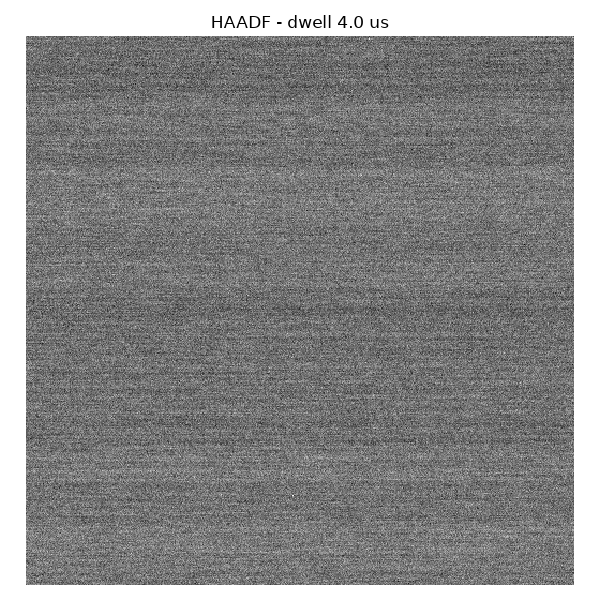

In [26]:
scan.dwell_time = 4e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]
scan.output_format = ".h5"
microscope.set_fov(348*1e-9)

print("dwell_time :", scan.dwell_time)
print("image size :", scan.imsize)
print("scan region:", list(scan.scan_region))
print(f"scan FOV  {microscope.fov*1e9:.1f}nm")
data_key = microscope.acquire_scanned_image(["haadf"])

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

## Focus with Sample Height

dwell_time : 4e-06
image size : 512
scan FOV  170.0nm


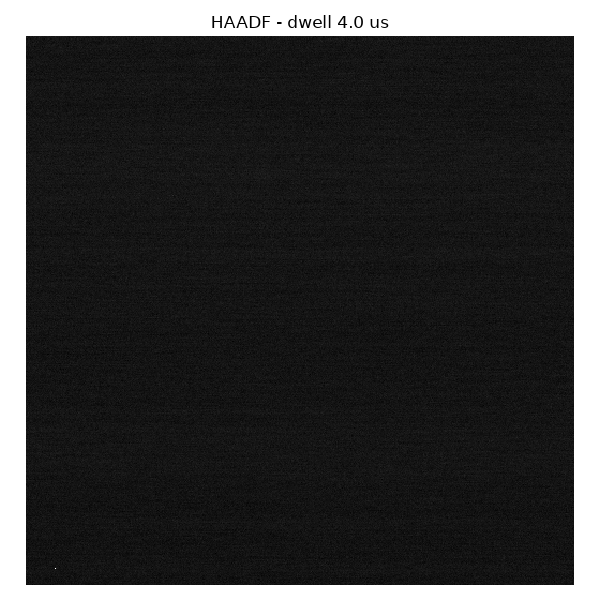

In [39]:
move_z = -.001*1e-6

starting_position = microscope.get_stage()
new_position = starting_position + np.array([0, 0, move_z, 0, 0])[:len(starting_position)]
microscope.move_stage(new_position)

scan.dwell_time = 4e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]
scan.output_format = ".h5"
#microscope.set_fov(348*1e-9)
microscope.set_fov(.17*1e-6)

print("dwell_time :", scan.dwell_time)
print("image size :", scan.imsize)
# print("scan region:", list(scan.scan_region))
print(f"scan FOV  {microscope.fov*1e9:.1f}nm")
data_key = microscope.acquire_scanned_image(["haadf"])

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()


## Aberration Correction

Here we are using the tableau function of the CEOS SCORR software.

- tabtype can be "Fast", "Standard", "Enhanced"
- angle is in mili-radian
- We want the first orders from this defocus=C1=C$_{1,0}$, astigmatismus A1,B2, A2

### Correcting 1st and 2nd orders

In [ ]:

microscope.set_fov(348*1e-9)

ab_msg = corrector_proxy.acquire_tableau('Fast  1')
ab = {}
tableau_result_12 = json.loads(ab_msg)['result']['aberrations']

def carth2polar(z):
    return np.linalg.norm(z), np.degrees(np.arctan2(z[1], z[0]))
print('First and Second Order Aberrations"')
print(f" C1: {ab['C1'][0]*1e9:9.1f} nm ")
for key in ['A1', 'B2', 'A2']:
    amplitude , angle = carth2polar(tableau_result_12[key])                                         
    print(f" {key}: {amplitude*1e9:9.1f} nm {angle:9.1f} deg")
print(f" WD: {np.linalg.norm(tableau_result_12['WD'])*1e3:9.1f} mrad ")

### Correct First and Second Orders

In [ ]:
def correct(key, v):
    """
    Send a correction via the Tango proxy.
    Scalar keys (WD, C1, C3) → "KEY x"
    Vector keys              → "KEY x y"
    """
    v = list(v)
    if key in ['C1', 'C3', 'WD']:
        corrector_proxy.correct_aberration(f"{key} {v[0]}")
    else:
        corrector_proxy.correct_aberration(f"{key} {v[0]} {v[1]}")


def correct_12(ab):
    """Correct 1st and 2nd order. Returns list of corrected keys."""
    thresholds = {'WD': 1e-3, 'C1': 5e-9, 'A1': 5e-9, 'B2': 50e-9, 'A2': 100e-9}
    corrected = []
    for key in thresholds.keys():
        if np.linalg.norm(ab.get(key, [0, 0])) > thresholds[key]:
            correct(key, ab[key])
            corrected.append(key)
    return corrected




correct_12(tableau_result_12)



['B2']

And this can be run till we reach desired correction

In [ ]:
corrected = ['1']
while len(corrected)>0:
    ab_msg = corrector_proxy.acquire_tableau('Fast  1')
    ab = {}
    tableau_result_12 = json.loads(ab_msg)['result']['aberrations']

    corrected = correct_12(tableau_result_12)
    print(corrected)

print('done')

[]
done


### Correct 3rd and 4th order Aberrations
We do the tableau with a much larger angle now, and with much more different angles ('Enhanced')

In [ ]:
microscope.set_fov(348*1e-9)

ab_msg = corrector_proxy.acquire_tableau('Enhanced  40')
ab = {}
tableau_result = json.loads(ab_msg)['result']['aberrations']

print(f" {'C3'}: {tableau_result['C3']*1e9:9.1f} nm ")
for key in [, 'S3', 'A3', 'A4', 'D4', 'B4']:
    amplitude , angle = carth2polar(tableau_result[key])                                         
    print(f" {key}: {amplitude*1e9:9.1f}nm {angle:9.1f}deg")


 C3: 6849.20nm 0.00deg
 S3: 160.26nm 45.23deg
 A3: 129.38nm 44.72deg
 A4: 1977.20nm -99.13deg
 D4: 10022.48nm -130.82deg
 B4: 411.50nm 156.61deg


### Aberration correction GUI

Workflow (mirrors the original nested-loop design):

outer loop — repeat until 3rd+4th order clean:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; inner loop — repeat Fast 1 until 1st+2nd order clean

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;  Enhanced 40 measurement

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; correct 3rd order  (if anything bad)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; else correct 4th order

In [ ]:
"""
Aberration Correction GUI
=========================
Paste into a Jupyter notebook cell.  Requires in the cell above:

    %matplotlib widget

Assumes `corrector_proxy` is a Tango DeviceProxy already in scope.

Probe panel:
    Swap the two commented lines in update_probe() to use real pt.get_probe().
"""

import json
import threading

import ipywidgets as widgets
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

# ── Aberration configuration ──────────────────────────────────────────────────

first_order  = ['WD', 'C1', 'A1']
second_order = ['B2', 'A2']
third_order  = ['C3', 'S3', 'A3']
fourth_order = ['A4', 'D4', 'B4']
all_keys     = first_order + second_order + third_order + fourth_order

# WD, C1, C3 are scalar — Tango server expects "KEY x" (one float).
# All others are 2-component — expects "KEY x y".
SCALAR_KEYS = {'WD', 'C1', 'C3'}

fourth_order_factor = 0.50

thresholds = {
    'WD': 1e-3,   'C1': 5e-9,   'A1': 5e-9,
    'B2': 50e-9,  'A2': 100e-9,
    'C3': 0.7e-6, 'S3': 0.7e-6, 'A3': 1e-6,
    'A4': 5e-6,   'D4': 4e-6,   'B4': 5e-6,
}

display_scale = {
    'WD': 1e3,  'C1': 1e9,  'A1': 1e9,
    'B2': 1e9,  'A2': 1e9,
    'C3': 1e9,  'S3': 1e9,  'A3': 1e9,
    'A4': 1e6,  'D4': 1e6,  'B4': 1e6,
}
display_units = {
    'WD': 'mm', 'C1': 'nm', 'A1': 'nm',
    'B2': 'nm', 'A2': 'nm',
    'C3': 'nm', 'S3': 'nm', 'A3': 'nm',
    'A4': 'µm', 'D4': 'µm', 'B4': 'µm',
}

order_groups = {
    '1st': {'keys': first_order,  'color': '#00d4ff'},
    '2nd': {'keys': second_order, 'color': '#00e87a'},
    '3rd': {'keys': third_order,  'color': '#ffc400'},
    '4th': {'keys': fourth_order, 'color': '#ff6b35'},
}

key_colors = {
    # 1st order: bright cyan → teal → steel blue
    'WD': '#00d4ff', 'C1': '#00888a', 'A1': '#2255cc',
    # 2nd order: bright green → olive
    'B2': '#00e87a', 'A2': '#88cc00',
    # 3rd order: bright yellow → amber → orange-yellow
    'C3': '#ffc400', 'S3': '#dd7700', 'A3': '#ffee44',
    # 4th order: bright orange → crimson → salmon
    'A4': '#ff6b35', 'D4': '#cc1133', 'B4': '#ff99aa',
}

# ── Hardware interface ────────────────────────────────────────────────────────

def norm(v):
    return float(np.linalg.norm(v))


def acquire(tableau_type):
    """
    Run a tableau and return the aberrations dict.
    tableau_type: e.g. 'Fast 1', 'Enhanced 40'
    """
    raw = corrector_proxy.acquire_tableau(tableau_type)
    return json.loads(raw)['result']['aberrations']


def correct(key, v):
    """
    Send a correction via the Tango proxy.
    Scalar keys (WD, C1, C3) → "KEY x"
    Vector keys              → "KEY x y"
    """
    v = list(v)
    if key in SCALAR_KEYS:
        corrector_proxy.correct_aberration(f"{key} {v[0]}")
    else:
        corrector_proxy.correct_aberration(f"{key} {v[0]} {v[1]}")


def correct_12(ab):
    """Correct 1st and 2nd order. Returns list of corrected keys."""
    corrected = []
    for key in first_order + second_order:
        if norm(ab.get(key, [0, 0])) > thresholds[key]:
            correct(key, ab[key])
            corrected.append(key)
    return corrected


def correct_3rd(ab):
    """
    Correct 3rd order. C3 gates S3/A3 — if C3 is bad, skip S3/A3.
    Returns list of corrected keys.
    """
    corrected = []
    if norm(ab.get('C3', [0, 0])) > thresholds['C3']:
        correct('C3', ab['C3'])
        corrected.append('C3')
    else:
        for key in ['S3', 'A3']:
            if norm(ab.get(key, [0, 0])) > thresholds[key]:
                correct(key, ab[key])
                corrected.append(key)
    return corrected


def correct_4th(ab, factor):
    """Correct 4th order with partial factor. Returns list of corrected keys."""
    corrected = []
    for key in fourth_order:
        if norm(ab.get(key, [0, 0])) > thresholds[key]:
            correct(key, [v * factor for v in ab[key]])
            corrected.append(key)
    return corrected

# ── Figure layout ─────────────────────────────────────────────────────────────

plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 9), facecolor='#07070f')
try:
    fig.canvas.header_visible = False
except AttributeError:
    pass

gs = gridspec.GridSpec(
    2, 5,
    figure=fig,
    left=0.04, right=0.98, top=0.93, bottom=0.07,
    wspace=0.40, hspace=0.50,
    width_ratios=[1, 1, 1, 1, 1],
    height_ratios=[1.1, 1],
)

ax_probe = fig.add_subplot(gs[0, 0])
ax_bars  = fig.add_subplot(gs[0, 1:])
ax_hist  = {
    '1st': fig.add_subplot(gs[1, 0]),
    '2nd': fig.add_subplot(gs[1, 1]),
    '3rd': fig.add_subplot(gs[1, 2]),
    '4th': fig.add_subplot(gs[1, 3:]),
}

for ax in [ax_probe, ax_bars] + list(ax_hist.values()):
    ax.set_facecolor('#0c0c18')
    for sp in ax.spines.values():
        sp.set_color('#1e1e35')

# ── Probe panel ───────────────────────────────────────────────────────────────

ax_probe.set_title('probe  ·  real space', fontsize=8, color='#00d4ff', pad=4, loc='left')
ax_probe.set_xticks([])
ax_probe.set_yticks([])
probe_im = ax_probe.imshow(
    np.zeros((64, 64)), cmap='hot', vmin=0, vmax=1,
    interpolation='nearest', origin='lower',
)
cb = fig.colorbar(probe_im, ax=ax_probe, fraction=0.046, pad=0.02)
cb.ax.tick_params(labelsize=7, colors='#555')

# ── Bar panel ─────────────────────────────────────────────────────────────────

ax_bars.set_title(
    'aberrations  ·  normalised amplitude  (dashed = threshold)',
    fontsize=8, color='#aaaacc', pad=4, loc='left',
)
ax_bars.set_xlim(-0.5, len(all_keys) - 0.5)
ax_bars.set_xticks(range(len(all_keys)))
ax_bars.set_xticklabels(all_keys, fontsize=8)
ax_bars.set_ylim(0, 4.5)
ax_bars.set_yticks([0, 1, 2, 3, 4])
ax_bars.set_yticklabels(['0', '1× thr', '2×', '3×', '4×'], fontsize=7, color='#555')
ax_bars.tick_params(colors='#555', labelsize=8)
ax_bars.axhline(1.0, color='#ffffff22', linewidth=0.8, linestyle='--')

bar_rects = ax_bars.bar(
    range(len(all_keys)),
    [0] * len(all_keys),
    color=[key_colors[k] for k in all_keys],
    alpha=0.75,
    edgecolor='none',
    width=0.6,
)

for ord_name, grp in order_groups.items():
    idx = [all_keys.index(k) for k in grp['keys']]
    ax_bars.text(
        np.mean(idx), 4.3, ord_name,
        ha='center', va='bottom', fontsize=7,
        color=grp['color'], alpha=0.7,
    )

# ── History panels ────────────────────────────────────────────────────────────

history_lines = {}
for ord_name, grp in order_groups.items():
    ax   = ax_hist[ord_name]
    key0 = grp['keys'][0]
    ax.set_title(
        f"{ord_name} order  [{display_units[key0]}]",
        fontsize=8, color=grp['color'], pad=3, loc='left',
    )
    ax.tick_params(colors='#444', labelsize=7)
    ax.set_xlabel('iteration', fontsize=7, color='#333')
    ax.set_ylim(0, 1)

    history_lines[ord_name] = {}
    for k in grp['keys']:
        ax.axhline(
            thresholds[k] * display_scale[k],
            color=key_colors[k], linewidth=0.6, linestyle=':', alpha=0.4,
        )
        line, = ax.plot(
            [], [], color=key_colors[k],
            linewidth=1.4, label=k,
            marker='o', markersize=2.5,
        )
        history_lines[ord_name][k] = line

    leg = ax.legend(fontsize=7, loc='upper right',
                    facecolor='#0c0c18', edgecolor='#1e1e35')
    for text, k in zip(leg.get_texts(), grp['keys']):
        text.set_color(key_colors[k])

# ── Status text ───────────────────────────────────────────────────────────────

status_text = fig.text(
    0.5, 0.965, 'ready — press RUN',
    ha='center', va='top', fontsize=9,
    color='#555', fontfamily='monospace',
)

# ── Runtime state ─────────────────────────────────────────────────────────────

# history indexed by measurement number (each acquire() call = one entry)
history     = {k: [] for k in all_keys}
_stop_flag  = threading.Event()

# ── Live update functions ─────────────────────────────────────────────────────

def update_probe(ab):
    """
    Simulated probe.  Replace block with:
        probe, _, _ = pt.get_probe(ab, 512, 512)
        probe_im.set_data(np.abs(probe) ** 2)
        probe_im.autoscale()
    """
    N      = 64
    C1_nm  = norm(ab.get('C1', [0, 0])) * 1e9
    A1_v   = ab.get('A1', [0, 0])
    A1_nm  = norm(A1_v) * 1e9
    A1_ang = np.arctan2(A1_v[1], A1_v[0])
    C3_nm  = norm(ab.get('C3', [0, 0])) * 1e9
    sigma   = 3.5 * (1 + C1_nm / 5 * 0.5 + C3_nm / 350 * 0.3)
    astig   = min(A1_nm / 5 * 0.6, 2.0)
    y, x    = np.ogrid[:N, :N]
    dx, dy  = x - N / 2, y - N / 2
    phi     = np.arctan2(dy, dx)
    r       = np.hypot(dx, dy)
    sig_eff = sigma * (1 + astig * np.cos(2 * (phi - A1_ang)) * 0.25)
    probe   = np.exp(-r ** 2 / (2 * sig_eff ** 2))
    probe  /= probe.max()
    probe_im.set_data(probe)
    probe_im.set_clim(0, 1)


def record_and_redraw(ab, measured_keys=None):
    """
    Append measurement to history.
    measured_keys: list of keys actually measured in this tableau.
                   Keys NOT in this list repeat their last known value
                   rather than being recorded as 0.
    If measured_keys is None, all keys are treated as measured.
    """
    if measured_keys is None:
        measured_keys = all_keys
    for k in all_keys:
        if k in measured_keys:
            history[k].append(norm(ab.get(k, [0, 0])))
        else:
            # repeat last known value (or 0 if no history yet)
            last = history[k][-1] if history[k] else 0.0
            history[k].append(last)
    update_bars(ab)
    update_probe(ab)
    update_history()
    redraw()


def update_bars(ab):
    for i, k in enumerate(all_keys):
        amp        = norm(ab.get(k, [0, 0]))
        normalised = amp / thresholds[k]
        bar_rects[i].set_height(min(normalised, 4.5))
        bar_rects[i].set_alpha(0.9 if amp > thresholds[k] else 0.30)


def update_history():
    n = len(history[all_keys[0]])
    if n == 0:
        return
    iters = list(range(1, n + 1))
    for ord_name, grp in order_groups.items():
        ax       = ax_hist[ord_name]
        all_vals = []
        for k in grp['keys']:
            y = [v * display_scale[k] for v in history[k]]
            history_lines[ord_name][k].set_data(iters, y)
            all_vals.extend(y)
        ax.set_xlim(1, max(n, 2))
        if all_vals:
            ymax   = max(all_vals) * 1.25
            yfloor = thresholds[grp['keys'][0]] * display_scale[grp['keys'][0]] * 1.5
            ax.set_ylim(0, max(ymax, yfloor))


def redraw():
    fig.canvas.draw_idle()

# ── Correction loop ───────────────────────────────────────────────────────────

def run_correction(max_outer, fourth_factor, log_out):
    """
    Mirrors the original workflow:

        outer loop (Enhanced):
            inner loop (Fast) until 1st+2nd clean
            Enhanced 40 measurement
            correct 3rd  →  if anything corrected, next outer iteration
            else correct 4th  →  if anything corrected, next outer iteration
            else done
    """
    _stop_flag.clear()

    with log_out:
        log_out.clear_output(wait=True)
        print('─' * 52)
        print(f'  Aberration correction  —  max {max_outer} outer iterations')
        print('─' * 52)

    def stopped():
        if _stop_flag.is_set():
            with log_out:
                print('\n  ⚠  Stopped by user.')
            status_text.set_text('stopped')
            status_text.set_color('#ff4444')
            redraw()
            return True
        return False

    def safe_acquire(tableau_type, label):
        try:
            return acquire(tableau_type)
        except Exception as exc:
            with log_out:
                print(f'  ERROR acquiring {label}: {exc}')
            status_text.set_text('error')
            status_text.set_color('#ff4444')
            redraw()
            return None

    # ── outer loop ────────────────────────────────────────────────────────────
    for outer in range(max_outer):
        if stopped(): return

        with log_out:
            print(f'\n━━  Outer iteration {outer + 1}/{max_outer}  ━━')

        # ── inner loop: Fast 1 until 1st+2nd clean ────────────────────────
        inner = 0
        while True:
            if stopped(): return
            inner += 1
            with log_out:
                print(f'  [Fast]  inner iter {inner}')
            status_text.set_text(f'outer {outer+1}  ·  Fast iter {inner}')
            status_text.set_color('#00d4ff')
            redraw()

            ab = safe_acquire('Fast 1', 'Fast 1')
            if ab is None: return

            record_and_redraw(ab, measured_keys=first_order + second_order)

            corrected_12 = correct_12(ab)
            with log_out:
                tag = ', '.join(corrected_12) if corrected_12 else '(none — 1st/2nd clean)'
                print(f'    corrected: {tag}')

            #if not corrected_12:
            break   # 1st+2nd order converged → move to Enhanced

        # ── Enhanced 40 measurement + 3rd/4th correction ──────────────────
        if stopped(): return
        with log_out:
            print(f'  [Enhanced]')
        status_text.set_text(f'outer {outer+1}  ·  Enhanced 40')
        status_text.set_color('#ffc400')
        redraw()

        ab_enh = safe_acquire('Enhanced 40', 'Enhanced 40')
        if ab_enh is None: return

        record_and_redraw(ab_enh, measured_keys=all_keys)

        corrected_3 = correct_3rd(ab_enh)
        if corrected_3:
            with log_out:
                print(f'    3rd order corrected: {corrected_3}')
            # go back to top of outer loop (re-do inner Fast loop)
            continue

        corrected_4 = correct_4th(ab_enh, fourth_factor)
        if corrected_4:
            with log_out:
                print(f'    4th order corrected: {corrected_4}')
            # go back to top of outer loop
            continue

        # Nothing corrected in 3rd or 4th — fully converged
        with log_out:
            print(f'\n  ✦  Converged after outer iteration {outer + 1}.')
        status_text.set_text(f'converged — outer iter {outer + 1}')
        status_text.set_color('#00e87a')
        redraw()
        return

    with log_out:
        print(f'\n  Done — {max_outer} outer iterations complete.')
    status_text.set_text('done')
    status_text.set_color('#00e87a')
    redraw()

# ── Widget controls ───────────────────────────────────────────────────────────

w_max_iter = widgets.BoundedIntText(
    value=5, min=1, max=20, step=1,
    description='Max outer:',
    style={'description_width': '70px'},
    layout=widgets.Layout(width='160px'),
)
w_fourth_factor = widgets.BoundedFloatText(
    value=0.5, min=0.05, max=1.0, step=0.05,
    description='4th ×:',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='150px'),
)
w_run = widgets.Button(
    description='▶  RUN',
    style={'button_color': '#001a20', 'font_weight': 'bold'},
    layout=widgets.Layout(width='100px', height='32px'),
)
w_stop = widgets.Button(
    description='■  STOP',
    button_style='danger',
    layout=widgets.Layout(width='100px', height='32px'),
)
log_out = widgets.Output(
    layout=widgets.Layout(
        width='100%', height='220px',
        overflow_y='auto',
        padding='8px 12px',
    )
)

log_panel = widgets.VBox(
    [
        widgets.HTML(value=(
            '<div style="'
            'font-family:monospace;'
            'font-size:10px;'
            'letter-spacing:4px;'
            'color:#334;'
            'background:#0a0a14;'
            'padding:5px 12px 4px 12px;'
            'border-bottom:1px solid #1a1a30;'
            '">OUTPUT LOG</div>'
        )),
        log_out,
    ],
    layout=widgets.Layout(border='1px solid #1a1a30', width='100%'),
)

_thread = None

def on_run(_):
    global _thread, history
    history = {k: [] for k in all_keys}
    for ord_name, grp in order_groups.items():
        for k in grp['keys']:
            history_lines[ord_name][k].set_data([], [])
    _thread = threading.Thread(
        target=run_correction,
        args=(w_max_iter.value, w_fourth_factor.value, log_out),
        daemon=True,
    )
    _thread.start()

def on_stop(_):
    _stop_flag.set()

w_run.on_click(on_run)
w_stop.on_click(on_stop)

controls = widgets.HBox(
    [w_max_iter, w_fourth_factor, w_run, w_stop],
    layout=widgets.Layout(gap='12px', align_items='center', padding='6px 0'),
)

display(widgets.VBox([controls, log_panel], layout=widgets.Layout(gap='6px')))
plt.show()

### Get Image

In [ ]:
scan.dwell_time = 4e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]
scan.output_format = ".h5"
microscope.set_fov(200*1e-9)

data_key = microscope.acquire_scanned_image(["haadf"])

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

### Focus and Stigmation with OptiSTEM

defocus: -40.6nm


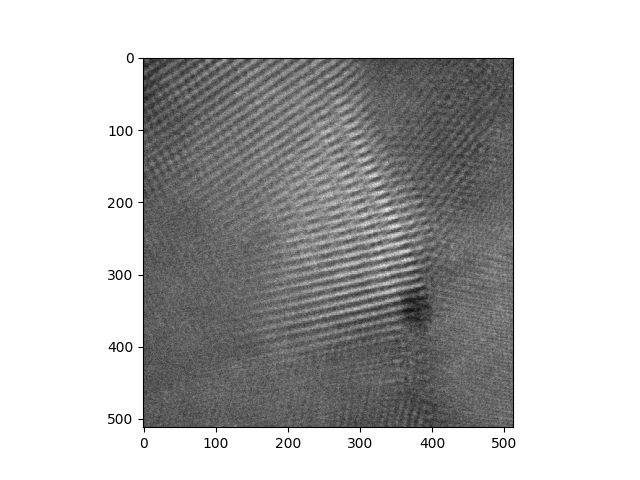

In [9]:
microscope.optics.scan_field_of_view  = 10*1e-9

settings = RunOptiStemSettings(method=OptiStemMethod.C1_A1, dwell_time=2*1e-6, cutoff_in_pixels=5)
microscope.auto_functions.run_opti_stem(settings)
print(f"defocus: {microscope.optics.defocus*1.e9:.1f}nm")
haadf_image = microscope.acquisition.acquire_stem_image(DetectorType.HAADF, 512, 4e-6)# haadf is pixel wise
fig = plt.figure()
im =  plt.imshow(haadf_image.data, cmap='gray')


In [3]:
microscope.get_command_list()

NameError: name 'microscope' is not defined

### Take high resolution Image

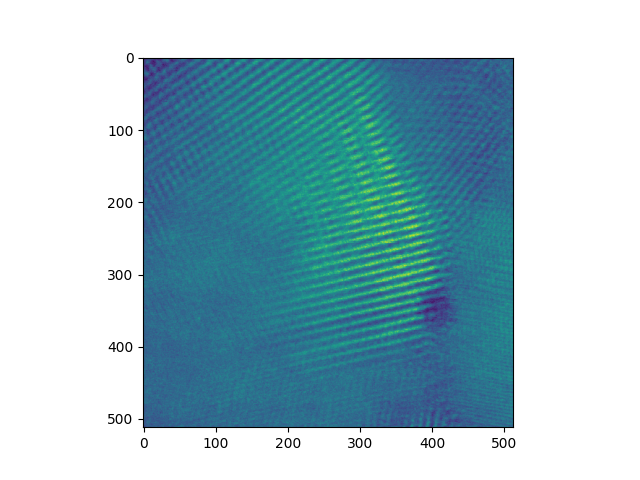

In [10]:
#microscope.optics.defocus = -39e-9
microscope.optics.scan_field_of_view  = 10*1e-9
haadf_image = microscope.acquisition.acquire_stem_image(DetectorType.HAADF, 512, 16e-6)# haadf is pixel wise
fig = plt.figure()
im =  plt.imshow(haadf_image.data)

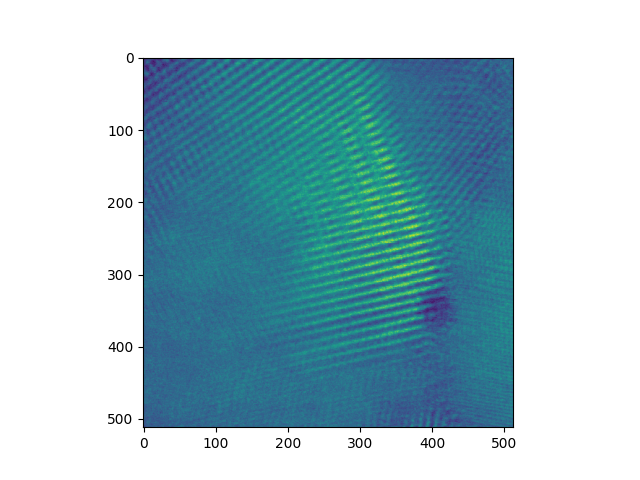

In [13]:

fig = plt.figure()
im =  plt.imshow(haadf_image.data)

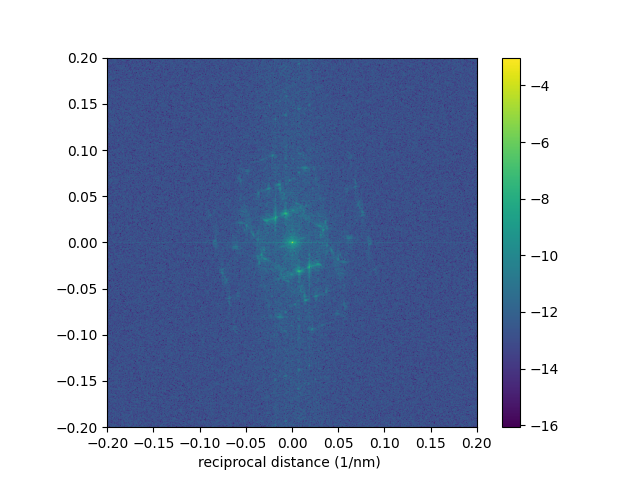

In [40]:
im_fft = np.fft.fftshift(np.fft.fft2(haadf_image.data))
im_fft = np.abs(im_fft)
im_fft /= im_fft.sum()
extent = [-2/10,2/10, -2/10,2/10]

plt.figure()
plt.imshow(np.log(.0000001+np.abs(im_fft)), extent=extent)
axis = 10
plt.xlabel('reciprocal distance (1/nm) ' )
plt.colorbar()

## End Session

In [11]:
#microscope.specimen.stage.absolute_move([0,0, 0])
print(microscope.specimen.stage.position*1e6)
microscope.vacuum.column_valves.close()
print("column valve is: ", microscope.vacuum.column_valves.state)

StagePosition(x=19.482495, y=-12.09846, z=-84.67863, a=90.551)
column valve is:  Closed


## Conclusions

Remote Aberration Correciton is not any faster - Some Machine Learning has to happen - 

but it allows to adopt workflows that work for your microscope
